## Exercise: Hierarchical Clustering

#### In this exercise, we will test our understanding of the core concepts of hierarchical clustering

### **Learning Objectives**
#### By the end of this exercise, you should be able to:
#### - Implement an optimal agglomerative hierarchical clustering model

In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/wine_clustering.csv')
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


### Exercises

#### **Exercise 1: Feature Scaling**
#### The first step in our process is feature scaling. By scaling the features to a uniform range, we prevent attributes with larger magnitudes from dominating the distance calculations, thus ensuring more balanced clustering results.

#### Perform feature scaling, using `StandardScaler` on the dataset to ensure that all features contribute equally to the clustering process.

In [4]:
scaler = StandardScaler()

scaled_df = scaler.fit_transform(data)

In [5]:
scaled_df

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

### **Exercise 2: Hierarchical clustering and dendogram visualisation**

#### Next, we want to gain some insights into the hierarchical structure of our clusters to be able to determine the optimal number of clusters to use in our model by applying the hierarchical clustering algorithm to our scaled data.

#### Compute the hierarchical clustering of the data using the `ward` method then visualise the resulting clusters as a dendogram. Based in the dendogram, how many clusters should we use for our model?

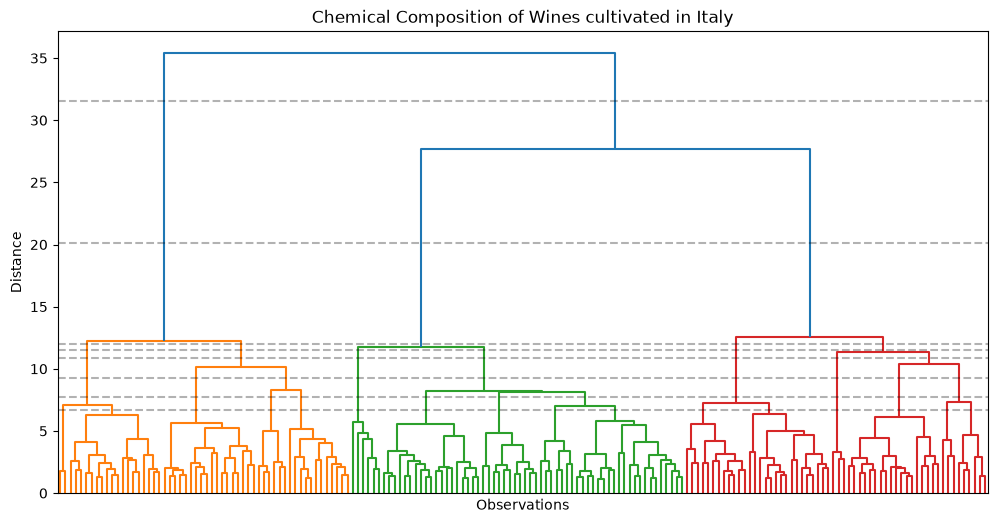

In [7]:
import scipy.cluster.hierarchy as sch

linkage_matrix = sch.linkage(
    scaled_df,
    method='ward'
)

plt.figure(figsize=(12, 6))
sch.dendrogram(
    linkage_matrix,
    no_labels=True
)

z = linkage_matrix[:, 2]
gaps = np.diff(z)
largest_gap_indices = np.argsort(gaps)[-8:]

for idx in largest_gap_indices:
    cut_height = (z[idx] + z[idx + 1]) / 2

    plt.axhline(
        y=cut_height,
        color='black',
        linestyle='--',
        alpha=0.3
    )

plt.title('Chemical Composition of Wines cultivated in Italy')
plt.xlabel('Observations')
plt.ylabel('Distance')

plt.show()

### Question 3: Agglomerative clustering

#### Perform agglomerative clustering on the scaled data using the `AgglomerativeClustering` class from sklearn and 3 clusters

#### Print the resulting cluster labels

In [13]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = hc.fit_predict(scaled_df)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

### Question 4: Interpretation of cluster characteristics

#### After performing hierarchical clustering with 3 clusters, we have assigned each wine sample to one of these clusters. To better understand the characteristics of each cluster, we want to examine the average values of the 13 components in our dataset across the samples within each cluster.

#### Calculate the mean values of the 13 components for each cluster and compare the cluster's characteristics

#### **Note:** To get better visibility of the differences between clusters, it might be a good idea to visualise the cluster means using a **bar plot**, which, along with the dataframe, will provide a clearer and more intuitive understanding of the differences in chemical composition across the clusters.

#### Based on your observations, how would you describe the differences between the clusters in terms of their chemical composition?

In [14]:
data['cluster'] = labels

In [16]:
cluster_means = data.groupby('cluster').mean()

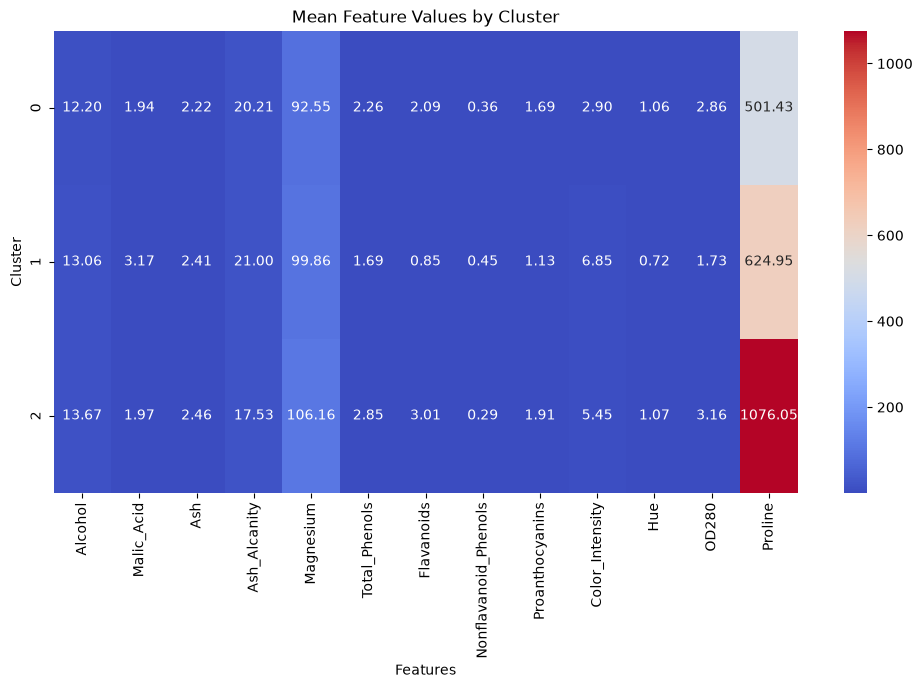

In [18]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_means,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Mean Feature Values by Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster')

plt.show()

In [20]:
cluster_means

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
cluster,,,,,,,,,,,,,
0,12.203966,1.938966,2.215172,20.208621,92.551724,2.262931,2.088103,0.355345,1.686552,2.895345,1.060000,2.862241,501.431034
1,13.061607,3.166607,2.412857,21.003571,99.857143,1.694286,0.847857,0.449464,1.129286,6.850179,0.721000,1.727321,624.946429
2,13.669219,1.970000,2.463125,17.528125,106.156250,2.850000,3.009688,0.291094,1.908125,5.450000,1.071406,3.158437,1076.046875


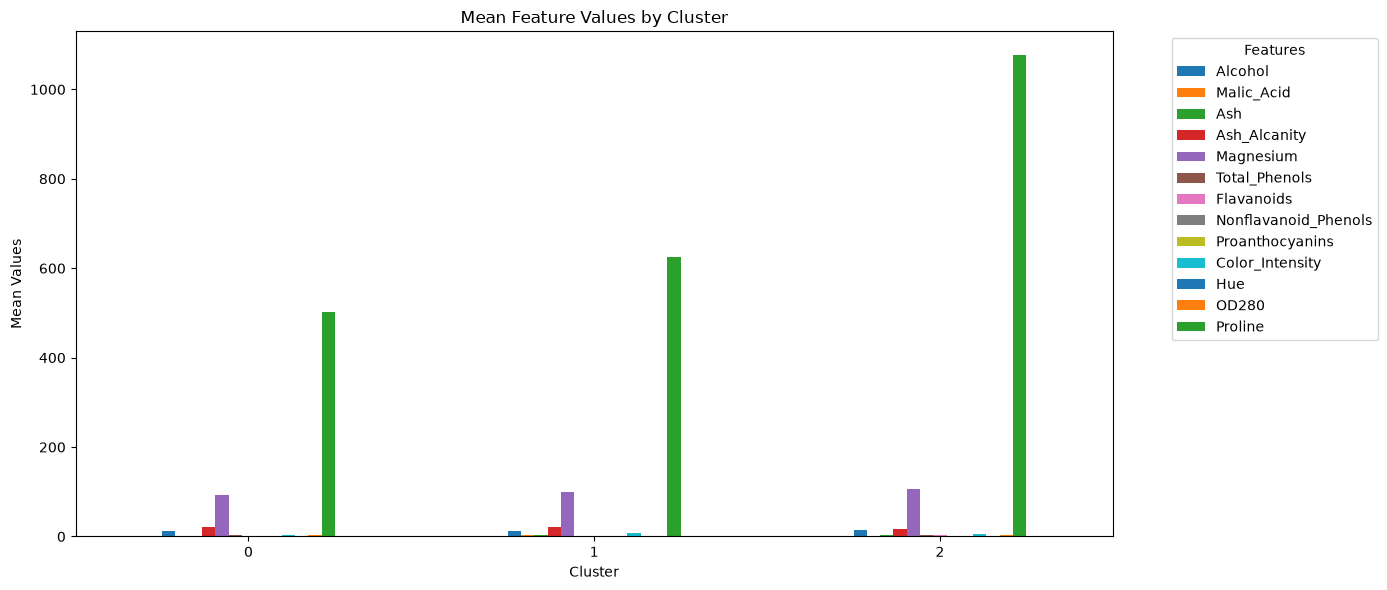

In [28]:
cluster_means.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Mean Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Values')
plt.xticks(rotation=0)
plt.legend(
    title='Features',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()